# P-QUICK – Example Convolution Run: ODs 91–99, 100 GHz

This notebook runs the full P-QUICK pipeline on Planck operational days 91–99
using detectors `100-1a`, `100-1b`, `100-2a`, `100-2b` and a CMB input sky.

**Key settings**
| Parameter | Value |
|-----------|-------|
| Sky ALM | `inputs/sky/alms_cmb0000.fits` (lmax 2048) |
| Pointings | OD 91–99 (`processed_od_009[1-9].npz`) |
| Detectors | 100-1a, 100-1b, 100-2a, 100-2b |
| lmax / mmax | 2048 / 14 |
| Coordinate system | `galactic` (set `resampling.coordinate_system: ecliptic` to keep the native frame) |
| nside | 1024 |

In [1]:
%pip install -q ducc0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path

# Ensure we run relative to the repo root regardless of where the kernel started
ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

print("Working directory:", ROOT)

Working directory: /Users/luca/Documents/Universita/SO/LAT/beam_windows_planck/P-QUICK


In [3]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from pquick.config import load_config
from pquick.utilities import build_pointing_file_paths, parse_mission_length

CONFIG_PATH = ROOT / "configs" / "od91_99_100ghz.yaml"
cfg = load_config(str(CONFIG_PATH))

# Verify pointing files resolve correctly
mission = cfg.inputs.pointing.mission_length or "full"
od_start, od_end = parse_mission_length(mission)
pointing_files = build_pointing_file_paths(cfg.inputs.pointing.input_root, od_start, od_end)
print(f"Config:         {CONFIG_PATH.name}")
print(f"Sky ALM:        {cfg.inputs.sky_alm}")
print(f"lmax / mmax:    {cfg.convolution.lmax} / {cfg.convolution.mmax}")
print(f"Coordinates:    {cfg.resampling.coordinate_system}")
print(f"nside:          {cfg.map.nside}")
print(f"Pointing files: {len(pointing_files)}")
for p in pointing_files:
    print(f"  {Path(p).name}")

Config:         od91_99_100ghz.yaml
Sky ALM:        inputs/sky/alms_cmb0000.fits
lmax / mmax:    1024 / 6
Coordinates:    galactic
nside:          512
Pointing files: 1
  processed_od_0091.npz


In [4]:
# Quick sanity-check on one OD and the sky ALM before running
from pquick.io import load_pointing_npz, load_sky_alm, infer_lmax_from_alm

if not pointing_files:
    print("No pointing files found. Check cfg.inputs.pointing.input_root and mission_length.")
else:
    npz = load_pointing_npz(pointing_files[0])
    print("=== First pointing file ===")
    print(f"  Samples (undersampled): {npz.time_us.size}")
    print(f"  Sampling rate:          {npz.sampling_rate_hz:.2f} Hz")
    print(f"  original_indices:       {'present' if npz.original_indices is not None else 'absent'}")
    print(f"  Flag fraction:          {(npz.flag != 0).mean():.3%}")

sky_alm = load_sky_alm(cfg.inputs.sky_alm)
lmax_sky = infer_lmax_from_alm(sky_alm)
print(f"\n=== Sky ALM ===")
print(f"  Shape:  {sky_alm.shape}  (ncomp, nalm)")
print(f"  lmax:   {lmax_sky}")

=== First pointing file ===
  Samples (undersampled): 5123
  Sampling rate:          180.38 Hz
  original_indices:       present
  Flag fraction:          8.598%

=== Sky ALM ===
  Shape:  (3, 525825)  (ncomp, nalm)
  lmax:   1024


In [5]:
import time as _time
from pquick.pipeline import run_pipeline

print("Running pipeline …")
t0 = _time.perf_counter()
out_path = run_pipeline(cfg)
elapsed = _time.perf_counter() - t0
print(f"Done in {elapsed:.1f} s")
print(f"Output: {out_path}")

Running pipeline …
[MPI] Serial run on host MacBook-Pro.local | ODs 91-91 (1 ODs)
Starting pipeline: 1 ODs on rank 0/1
[OD 1/1] processed_od_0091.npz
  [DET 1/4] 100-1a | native samples=15364776
    [chunk 1/1] samples 0:15364776 | good=14043786/15364776
  [DET 2/4] 100-1b | native samples=15364776
    [chunk 1/1] samples 0:15364776 | good=14043786/15364776
  [DET 3/4] 100-4a | native samples=15364776
    [chunk 1/1] samples 0:15364776 | good=14043786/15364776
  [DET 4/4] 100-4b | native samples=15364776
    [chunk 1/1] samples 0:15364776 | good=14043786/15364776
Done in 29.1 s
Output: outputs/od91_99_100ghz_nside1024_iqu.fits


In [6]:
prefix = cfg.map.output_prefix
outdir = Path(cfg.output.output_dir)

iqu  = hp.read_map(str(outdir / f"{prefix}_iqu.fits"),  field=(0,1,2), verbose=False)
hits = hp.read_map(str(outdir / f"{prefix}_hits.fits"), verbose=False)

t_map, q_map, u_map = iqu

print(f"Hit pixels:   {int((hits > 0).sum()):,}  / {hits.size:,}")
print(f"T  range:     {t_map[hits > 0].min():.4g}  –  {t_map[hits > 0].max():.4g}  µK")
print(f"Q  range:     {q_map[hits > 0].min():.4g}  –  {q_map[hits > 0].max():.4g}  µK")
print(f"U  range:     {u_map[hits > 0].min():.4g}  –  {u_map[hits > 0].max():.4g}  µK")
print(f"Median hits:  {np.median(hits[hits > 0]):.0f}")

Hit pixels:   19,542  / 3,145,728
T  range:     -1.637e+30  –  3.327e-09  µK
Q  range:     -1.637e+30  –  1.73e-08  µK
U  range:     -1.637e+30  –  1.633e-08  µK
Median hits:  2190


/var/folders/tm/8fyctf3n75z5vz3v82b9mym80000gn/T/ipykernel_51519/606624755.py:4: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  iqu  = hp.read_map(str(outdir / f"{prefix}_iqu.fits"),  field=(0,1,2), verbose=False)
/var/folders/tm/8fyctf3n75z5vz3v82b9mym80000gn/T/ipykernel_51519/606624755.py:5: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hits = hp.read_map(str(outdir / f"{prefix}_hits.fits"), verbose=False)


/var/folders/tm/8fyctf3n75z5vz3v82b9mym80000gn/T/ipykernel_51519/2876207764.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


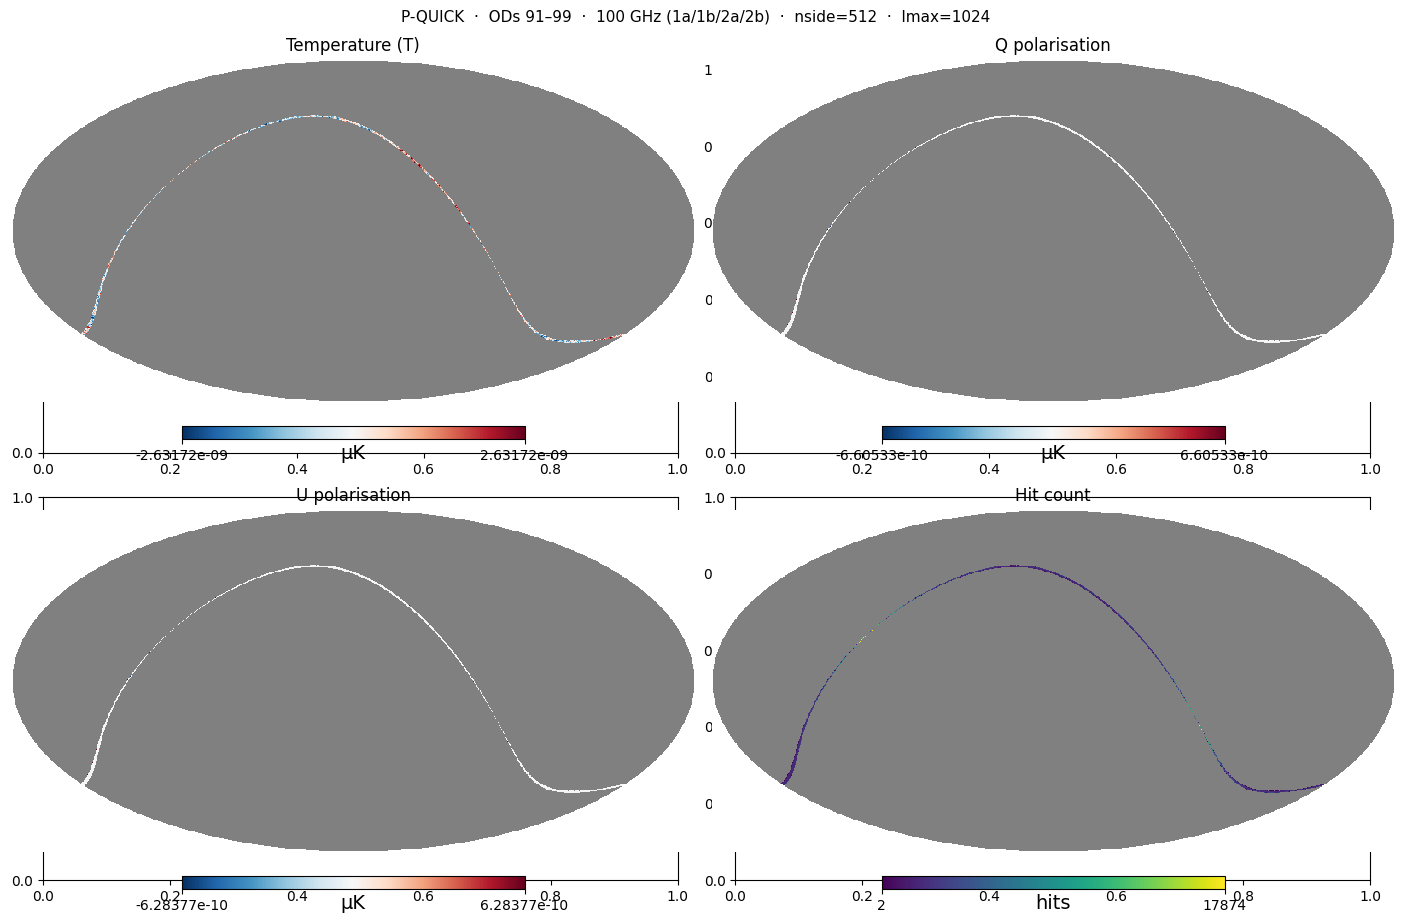

In [7]:
mask = hits > 0

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, data, title, unit in zip(
    axes.flat,
    [t_map, q_map, u_map, hits.astype(float)],
    ["Temperature (T)", "Q polarisation", "U polarisation", "Hit count"],
    ["µK", "µK", "µK", "hits"],
):
    if title == "Hit count":
        disp = data.copy()
        disp[~mask] = hp.UNSEEN
        vmin, vmax = None, None
    else:
        valid = data[mask]
        vmax = np.percentile(np.abs(valid), 99)
        vmin = -vmax
        disp = data.copy()
        disp[~mask] = hp.UNSEEN

    hp.mollview(
        disp,
        title=title,
        unit=unit,
        min=vmin,
        max=vmax,
        cmap="RdBu_r" if title != "Hit count" else "viridis",
        hold=False,
        fig=fig.number,
        sub=(2, 2, list(axes.flat).index(ax) + 1),
    )

plt.suptitle(
    f"P-QUICK  ·  ODs 91–99  ·  100 GHz (1a/1b/2a/2b)  ·  nside={cfg.map.nside}  ·  lmax={cfg.convolution.lmax}",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()